In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

from itertools import combinations


# ============================================================
# ПАРАМЕТРЫ ПОЛЬЗОВАТЕЛЯ
# ============================================================

N_FEATURES = 5          # количество признаков
N_SAMPLES = 300         # количество объектов

RANDOM_SEED = 42

# Диапазон корреляции между признаками
CORR_MIN = -0.8
CORR_MAX = 0.8

# Возможные распределения признаков
DISTRIBUTIONS = ["normal"]

# Какое распределение использовать:
# "random" -> случайно выбирается для каждого признака
# "normal" -> все признаки гауссовы
DISTRIBUTION_MODE = "random"

# Вероятность класса 1
CLASS_PROBABILITY = 0.5


# ============================================================
# ПАРАМЕТРЫ ГРАФИКОВ
# ============================================================

POINT_SIZE = 25
POINT_ALPHA = 0.55
POINT_COLOR = "steelblue"

LINE_COLOR = "darkred"
LINE_WIDTH = 2.0

# Количество параллельных сдвигов линии корреляции
N_CORRELATION_SHIFTS = 3

# Максимальный относительный сдвиг линии
CORRELATION_SHIFT = 0.15

# Показывать ли линии сдвига
SHOW_CORRELATION_SHIFTS = True

# Показывать ли класс цветом
COLOR_BY_CLASS = True

# Размер всей матрицы графиков
FIGSIZE_PER_PANEL = 3.5

In [50]:
# ============================================================
# ГЕНЕРАЦИЯ КОРРЕЛИРОВАННОГО DATASET
# ============================================================

def generate_random_correlation_matrix(
    n_features,
    corr_min=-0.8,
    corr_max=0.8,
    random_state=None
):
    """
    Генерирует случайную положительно определённую
    корреляционную матрицу.

    Диагональ = 1.
    Вне диагонали значения случайные.
    """

    rng = np.random.default_rng(random_state)

    # Случайная матрица
    A = rng.normal(size=(n_features, n_features))

    # Создаём симметричную матрицу
    covariance = A @ A.T

    # Переводим в корреляционную
    std = np.sqrt(np.diag(covariance))
    corr = covariance / np.outer(std, std)

    # Немного растягиваем корреляции
    # к пользовательскому диапазону
    mask = ~np.eye(n_features, dtype=bool)

    corr[mask] *= (
        rng.uniform(corr_min, corr_max, size=mask.sum())
        / np.maximum(np.abs(corr[mask]), 1e-12)
    )

    # После изменения матрица может перестать быть
    # положительно определённой.
    # Поэтому используем ближайшую PSD-матрицу.
    eigvals, eigvecs = np.linalg.eigh(corr)

    eigvals = np.maximum(eigvals, 1e-6)

    corr = (
        eigvecs
        @ np.diag(eigvals)
        @ eigvecs.T
    )

    # Нормализация диагонали
    std = np.sqrt(np.diag(corr))
    corr = corr / np.outer(std, std)

    np.fill_diagonal(corr, 1.0)

    return corr


def generate_dataset(
    n_samples,
    n_features,
    distributions=("normal",),
    distribution_mode="random",
    class_probability=0.5,
    random_state=None
):
    """
    Генерирует Dataset:

        X1, X2, ..., XN, class

    Признаки имеют случайные корреляции.
    """

    rng = np.random.default_rng(random_state)

    # --------------------------------------------------------
    # 1. Генерируем корреляционную матрицу
    # --------------------------------------------------------

    corr_matrix = generate_random_correlation_matrix(
        n_features=n_features,
        corr_min=CORR_MIN,
        corr_max=CORR_MAX,
        random_state=random_state
    )

    # --------------------------------------------------------
    # 2. Коррелированные нормальные данные
    # --------------------------------------------------------

    latent = rng.multivariate_normal(
        mean=np.zeros(n_features),
        cov=corr_matrix,
        size=n_samples
    )

    # --------------------------------------------------------
    # 3. Преобразуем признаки в нужные распределения
    # --------------------------------------------------------

    X = np.zeros_like(latent)

    for j in range(n_features):
        z = latent[:, j]
        X[:, j] = z

    # --------------------------------------------------------
    # 4. Создаём бинарный класс
    # --------------------------------------------------------

    y = rng.binomial(
        n=1,
        p=class_probability,
        size=n_samples
    )

    # --------------------------------------------------------
    # 5. DataFrame
    # --------------------------------------------------------

    feature_names = [
        f"X{i + 1}"
        for i in range(n_features)
    ]

    df = pd.DataFrame(
        X,
        columns=feature_names
    )

    df["class"] = y

    return df, corr_matrix, DISTRIBUTIONS

<Axes: >

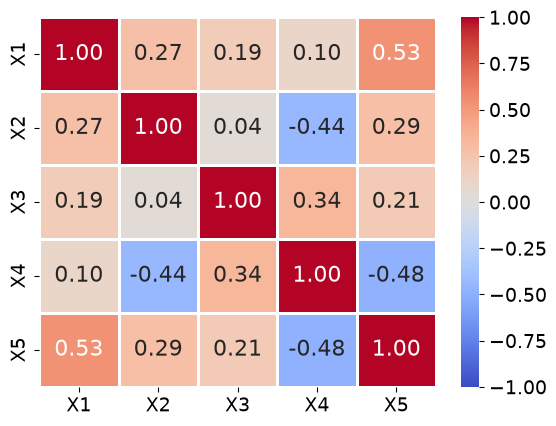

In [51]:
# ============================================================
# СОЗДАЁМ DATASET
# ============================================================
df, true_corr, distributions_used = generate_dataset(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    distributions=DISTRIBUTIONS,
    distribution_mode=DISTRIBUTION_MODE,
    class_probability=CLASS_PROBABILITY,
    random_state=RANDOM_SEED
)

corr = df.drop(columns="class").corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0,
                        fmt='.2f', linewidths=1, linecolor='white')


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoLocator, AutoMinorLocator
from matplotlib.lines import Line2D
from scipy import stats
from itertools import combinations
import math

# ============================================================
# ГЛОБАЛЬНЫЕ НАСТРОЙКИ ШРИФТА
# ============================================================
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 12


def custom_scatter(
    ax, x, y,                          # объект Axes и массивы координат X, Y
    class_values=None,                 # массив классов точек (0/1) для раскраски
    
    # === Шрифт ===
    font_family="DejaVu Sans",         # семейство шрифта для всех текстовых элементов
    font_size=16,                      # базовый размер шрифта
    
    # === Точки ===
    point_size=30,                     # размер маркеров точек
    point_alpha=0.55,                  # прозрачность точек (0..1)
    point_colors=None,                 # цвета для классов (None = авто)
    point_edgecolor="none",            # цвет обводки точек
    point_linewidth=0.5,               # толщина обводки точек
    point_marker="o",                  # форма маркера ("o" - круг, "s" - квадрат)
    
    # === Рамка ===
    spine_color="black",               # цвет рамок осей
    spine_width=1.5,                   # толщина рамок осей
    show_top_spine=True,               # показывать верхнюю рамку
    show_right_spine=True,             # показывать правую рамку
    
    # === Деления ===
    major_step="auto",                 # шаг основных делений (число или "auto")
    minor_step="auto",                 # шаг промежуточных делений (число или "auto")
    n_minor_ticks=4,                   # количество промежуточных делений между основными
    tick_length=6,                     # длина основных делений
    minor_tick_length=3,               # длина промежуточных делений
    tick_width=1.5,                    # толщина основных делений
    minor_tick_width=1,                # толщина промежуточных делений
    tick_direction="out",              # направление делений ("out", "in", "inout")
    tick_label_size=None,              # размер цифр на осях (None = font_size - 2)
    tick_label_color="black",          # цвет цифр на осях
    
    # === Сетка ===
    show_grid=True,                    # показывать сетку
    grid_which="major",                # по каким делениям рисовать сетку ("major", "minor", "both")
    grid_color="gray",                 # цвет сетки
    grid_alpha=0.25,                   # прозрачность сетки
    grid_linestyle="--",               # стиль линии сетки ("-", "--", ":", "-.")
    grid_linewidth=0.5,                # толщина линий сетки
    
    # === Подписи ===
    xlabel=None,                       # подпись оси X
    ylabel=None,                       # подпись оси Y
    label_size=None,                   # размер подписей осей (None = font_size)
    label_weight="normal",             # начертание подписей ("normal", "bold")
    
    # === Заголовок ===
    title=None,                        # заголовок графика
    title_size=None,                   # размер заголовка (None = font_size)
    title_weight="bold",               # начертание заголовка
    
    # === Регрессия ===
    show_correlation=True,             # показывать линию регрессии
    correlation_color="darkred",       # цвет линии регрессии
    correlation_width=2,               # толщина линии регрессии
    
    # === Доверительный интервал линии регрессии ===
    show_confidence_band=True,         # показывать доверительный интервал для линии регрессии
    confidence_band_color="orange",    # цвет доверительного интервала
    confidence_band_alpha=0.2,         # прозрачность доверительного интервала
    confidence_band_linestyle="-",     # стиль линии границ доверительного интервала
    confidence_band_linewidth=1,       # толщина линии границ доверительного интервала
    confidence_band_level=0.95,        # уровень доверия (0.95 = 95%)
    
    # === Интервал предсказания ===
    show_prediction_interval=True,     # показывать интервал предсказания для новых точек
    confidence_level=0.95,             # уровень доверия интервала предсказания
    interval_color="lightblue",        # цвет интервала предсказания
    interval_alpha=0.3,                # прозрачность интервала предсказания
    interval_linestyle="--",           # стиль линии границ интервала предсказания
    interval_linewidth=1,              # толщина линии границ интервала предсказания
    
    # === Интервалы значений ===
    show_intervals=True,               # показывать информацию об интервалах ΔX
    interval_position="top",           # положение текста интервалов ("top", "bottom")
    
    # === Легенда ===
    show_legend=True,                  # показывать легенду
    legend_loc="upper right",          # расположение легенды
    legend_fontsize=None,              # размер шрифта легенды (None = font_size - 4)
    legend_framealpha=0.9,             # прозрачность фона легенды
    
    # === Масштаб ===
    x_lim=None,                        # пределы оси X (min, max) или None для авто
    y_lim=None,                        # пределы оси Y (min, max) или None для авто
    equal_scale=False,                 # одинаковый физический масштаб осей X и Y
):
    """
    Построение scatter plot с регрессией, доверительным интервалом 
    и интервалом предсказания.
    """
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    
    # Значения по умолчанию для размеров шрифтов
    if tick_label_size is None:
        tick_label_size = max(font_size - 2, 8)
    if label_size is None:
        label_size = font_size
    if title_size is None:
        title_size = font_size
    if legend_fontsize is None:
        legend_fontsize = max(font_size - 4, 8)
    
    # --- Scatter ---
    if class_values is not None:
        classes = np.unique(class_values[~np.isnan(class_values)])
        
        if point_colors is None:
            colors = plt.cm.tab10(np.linspace(0, 1, max(len(classes), 1)))
        elif isinstance(point_colors, str):
            colors = [point_colors] * len(classes)
        else:
            colors = point_colors
        
        for cls, color in zip(classes, colors):
            mask = class_values == cls
            ax.scatter(
                x[mask], y[mask],
                s=point_size,
                alpha=point_alpha,
                color=color,
                marker=point_marker,
                edgecolors=point_edgecolor,
                linewidths=point_linewidth,
                label=f"Класс {int(cls)}",
                zorder=3
            )
    else:
        color = point_colors if isinstance(point_colors, str) else "steelblue"
        ax.scatter(
            x, y,
            s=point_size,
            alpha=point_alpha,
            color=color,
            marker=point_marker,
            edgecolors=point_edgecolor,
            linewidths=point_linewidth,
            zorder=3
        )
    
    # --- Корреляция и интервалы ---
    r = None
    dx_mean = None
    dx_median = None
    a = None
    b = None
    x_line = None
    y_line = None
    n = None
    x_mean = None
    residual_std = None
    ss_x = None
    
    if show_correlation and len(x) > 1:
        r = np.corrcoef(x, y)[0, 1]
        a, b = np.polyfit(x, y, 1)
        
        x_line = np.linspace(x.min(), x.max(), 300)
        y_line = a * x_line + b
        
        n = len(x)
        x_mean = np.mean(x)
        y_pred = a * x + b
        residuals = y - y_pred
        residual_std = np.sqrt(np.sum(residuals**2) / (n - 2))
        ss_x = np.sum((x - x_mean)**2)
        
        # Линия регрессии
        ax.plot(
            x_line, y_line,
            color=correlation_color,
            lw=correlation_width,
            zorder=4,
            label=f"r = {r:.3f}"
        )
        
        # Доверительный интервал линии регрессии (confidence band)
        if show_confidence_band and ss_x > 0:
            t_crit_ci = stats.t.ppf((1 + confidence_band_level) / 2, df=n-2)
            se_fit = residual_std * np.sqrt(1/n + (x_line - x_mean)**2 / ss_x)
            
            y_ci_upper = y_line + t_crit_ci * se_fit
            y_ci_lower = y_line - t_crit_ci * se_fit
            
            # Заливка доверительного интервала
            ax.fill_between(
                x_line, y_ci_lower, y_ci_upper,
                color=confidence_band_color,
                alpha=confidence_band_alpha,
                zorder=2,
                label=f"{confidence_band_level*100:.0f}% CI (линия)"
            )
            
            # Линии границ доверительного интервала
            ax.plot(
                x_line, y_ci_upper,
                color=confidence_band_color,
                linestyle=confidence_band_linestyle,
                linewidth=confidence_band_linewidth,
                alpha=min(confidence_band_alpha + 0.3, 1.0),
                zorder=3
            )
            ax.plot(
                x_line, y_ci_lower,
                color=confidence_band_color,
                linestyle=confidence_band_linestyle,
                linewidth=confidence_band_linewidth,
                alpha=min(confidence_band_alpha + 0.3, 1.0),
                zorder=3
            )
        
        # Интервал предсказания (prediction interval)
        if show_prediction_interval and ss_x > 0:
            t_crit_pi = stats.t.ppf((1 + confidence_level) / 2, df=n-2)
            se_pred = residual_std * np.sqrt(1 + 1/n + (x_line - x_mean)**2 / ss_x)
            
            y_pi_upper = y_line + t_crit_pi * se_pred
            y_pi_lower = y_line - t_crit_pi * se_pred
            
            ax.fill_between(
                x_line, y_pi_lower, y_pi_upper,
                color=interval_color,
                alpha=interval_alpha,
                zorder=2,
                label=f"{confidence_level*100:.0f}% PI (прогноз)"
            )
            
            ax.plot(
                x_line, y_pi_upper,
                color=interval_color,
                linestyle=interval_linestyle,
                linewidth=interval_linewidth,
                alpha=min(interval_alpha + 0.3, 1.0),
                zorder=3
            )
            ax.plot(
                x_line, y_pi_lower,
                color=interval_color,
                linestyle=interval_linestyle,
                linewidth=interval_linewidth,
                alpha=min(interval_alpha + 0.3, 1.0),
                zorder=3
            )
    
    # --- Delta X ---
    if show_intervals and len(x) > 1:
        dx = np.diff(np.sort(x))
        dx_mean = dx.mean()
        dx_median = np.median(dx)
    
    # --- Легенда ---
    if show_legend:
        legend_elements = []
        
        if class_values is not None:
            classes = np.unique(class_values[~np.isnan(class_values)])
            if point_colors is None:
                colors = plt.cm.tab10(np.linspace(0, 1, max(len(classes), 1)))
            elif isinstance(point_colors, str):
                colors = [point_colors] * len(classes)
            else:
                colors = point_colors
            
            for cls, color in zip(classes, colors):
                legend_elements.append(
                    Line2D([0], [0], marker=point_marker, color='w',
                           markerfacecolor=color, markersize=8,
                           label=f"Класс {int(cls)}")
                )
        
        if r is not None:
            legend_elements.append(
                Line2D([0], [0], marker='', color='w',
                       label=f"r = {r:.3f}")
            )
        
        if show_confidence_band:
            legend_elements.append(
                Line2D([0], [0], marker='', color=confidence_band_color,
                       linestyle='-', linewidth=2, alpha=0.7,
                       label=f"{confidence_band_level*100:.0f}% CI (линия регрессии)")
            )
        
        if show_prediction_interval:
            legend_elements.append(
                Line2D([0], [0], marker='', color=interval_color,
                       linestyle='--', linewidth=2, alpha=0.7,
                       label=f"{confidence_level*100:.0f}% PI (прогноз)")
            )
        
        if legend_elements:
            ax.legend(
                handles=legend_elements,
                loc=legend_loc,
                fontsize=legend_fontsize,
                framealpha=legend_framealpha,
                edgecolor='gray'
            )
    
    # --- Пределы ---
    if x_lim is not None:
        ax.set_xlim(x_lim)
    if y_lim is not None:
        ax.set_ylim(y_lim)
    
    # --- Spines ---
    for name, spine in ax.spines.items():
        spine.set_color(spine_color)
        spine.set_linewidth(spine_width)
    
    ax.spines["top"].set_visible(show_top_spine)
    ax.spines["right"].set_visible(show_right_spine)
    
    # --- Деления ---
    if major_step == "auto":
        ax.xaxis.set_major_locator(AutoLocator())
        ax.yaxis.set_major_locator(AutoLocator())
    else:
        ax.xaxis.set_major_locator(MultipleLocator(major_step))
        ax.yaxis.set_major_locator(MultipleLocator(major_step))
    
    if minor_step == "auto":
        ax.xaxis.set_minor_locator(AutoMinorLocator(n_minor_ticks))
        ax.yaxis.set_minor_locator(AutoMinorLocator(n_minor_ticks))
    else:
        ax.xaxis.set_minor_locator(MultipleLocator(minor_step))
        ax.yaxis.set_minor_locator(MultipleLocator(minor_step))
    
    ax.tick_params(
        which="major",
        direction=tick_direction,
        length=tick_length,
        width=tick_width,
        labelsize=tick_label_size,
        labelcolor=tick_label_color
    )
    ax.tick_params(
        which="minor",
        direction=tick_direction,
        length=minor_tick_length,
        width=minor_tick_width
    )
    
    # --- Grid ---
    if show_grid:
        ax.grid(
            which=grid_which,
            color=grid_color,
            alpha=grid_alpha,
            linestyle=grid_linestyle,
            linewidth=grid_linewidth
        )
    
    # --- Labels ---
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=label_size, fontweight=label_weight, fontfamily=font_family)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=label_size, fontweight=label_weight, fontfamily=font_family)
    if title is not None:
        ax.set_title(title, fontsize=title_size, fontweight=title_weight, fontfamily=font_family)
    
    if equal_scale:
        ax.set_aspect("equal", adjustable="box")
    
    return ax


def plot_pairs(
    df,                                # DataFrame с данными
    class_col="class",                 # название колонки с классами
    features=None,                     # список признаков (None = все кроме class_col)
    
    # === Размер панно ===
    subplot_size=6,                    # размер одного subplot в дюймах
    max_cols=3,                        # максимальное количество столбцов в панно
    padding=0.05,                      # отступ для global limits (доля от диапазона)
    
    # === Шрифт ===
    font_family="DejaVu Sans",         # семейство шрифта
    font_size=16,                      # базовый размер шрифта
    
    # === Точки ===
    point_size=30,                     # размер маркеров
    point_color=None,                  # цвет маркеров (None = авто по классам)
    point_alpha=0.55,                  # прозрачность маркеров
    point_edgecolor="none",            # цвет обводки маркеров
    point_linewidth=0.5,               # толщина обводки маркеров
    point_marker="o",                  # форма маркера
    
    # === Регрессия ===
    show_correlation=True,             # показывать линию регрессии
    correlation_color="darkred",       # цвет линии регрессии
    correlation_width=2,               # толщина линии регрессии
    
    # === Доверительный интервал линии регрессии ===
    show_confidence_band=True,         # показывать доверительный интервал для линии
    confidence_band_color="orange",    # цвет доверительного интервала
    confidence_band_alpha=0.2,         # прозрачность доверительного интервала
    confidence_band_linestyle="-",     # стиль линии границ
    confidence_band_linewidth=1,       # толщина линии границ
    confidence_band_level=0.95,        # уровень доверия
    
    # === Интервал предсказания ===
    show_prediction_interval=True,     # показывать интервал предсказания
    confidence_level=0.95,             # уровень доверия
    interval_color="lightblue",        # цвет интервала
    interval_alpha=0.3,                # прозрачность интервала
    interval_linestyle="--",           # стиль линии границ
    interval_linewidth=1,              # толщина линии границ
    
    # === Интервалы значений ===
    show_intervals=True,               # показывать информацию об интервалах ΔX
    
    # === Легенда ===
    show_legend=True,                  # показывать легенду
    
    # === Сетка ===
    show_grid=True,                    # показывать сетку
    
    # === Масштаб ===
    equal_scale=False,                 # одинаковый физический масштаб осей
    scale_mode="global",               # режим масштаба ("global" - общий, "individual" - индивидуальный)
    
    # === Заголовок фигуры ===
    suptitle="Все пары признаков",     # общий заголовок фигуры
    suptitle_size=18,                  # размер общего заголовка
):
    # Определяем признаки
    if features is None:
        features = [c for c in df.columns if c != class_col]
    
    pairs = list(combinations(features, 2))
    n_pairs = len(pairs)
    
    if n_pairs == 0:
        print("Недостаточно признаков для построения пар.")
        return
    
    # Автоматический подбор количества столбцов
    cols = min(max_cols, n_pairs)
    rows = math.ceil(n_pairs / cols)
    
    # Создаём фигуру оптимального размера
    fig, axes = plt.subplots(
        rows, cols,
        figsize=(subplot_size * cols, subplot_size * rows),
        squeeze=False
    )
    axes = axes.flatten()
    
    # Общий масштаб
    global_lim = None
    if scale_mode == "global":
        values = df[features].values
        vmin = values.min()
        vmax = values.max()
        d = vmax - vmin
        global_lim = (vmin - d * padding, vmax + d * padding)
    
    # Построение графиков
    for idx, (ax, (x_name, y_name)) in enumerate(zip(axes, pairs)):
        if scale_mode == "individual":
            x_lim = None
            y_lim = None
        else:
            x_lim = global_lim
            y_lim = global_lim
        
        custom_scatter(
            ax=ax,
            x=df[x_name],
            y=df[y_name],
            class_values=df[class_col] if class_col in df.columns else None,
            
            # Шрифт
            font_family=font_family,
            font_size=font_size,
            
            # Точки
            point_size=point_size,
            point_colors=point_color,
            point_alpha=point_alpha,
            point_edgecolor=point_edgecolor,
            point_linewidth=point_linewidth,
            point_marker=point_marker,
            
            # Регрессия
            show_correlation=show_correlation,
            correlation_color=correlation_color,
            correlation_width=correlation_width,
            
            # Доверительный интервал линии регрессии
            show_confidence_band=show_confidence_band,
            confidence_band_color=confidence_band_color,
            confidence_band_alpha=confidence_band_alpha,
            confidence_band_linestyle=confidence_band_linestyle,
            confidence_band_linewidth=confidence_band_linewidth,
            confidence_band_level=confidence_band_level,
            
            # Интервал предсказания
            show_prediction_interval=show_prediction_interval,
            confidence_level=confidence_level,
            interval_color=interval_color,
            interval_alpha=interval_alpha,
            interval_linestyle=interval_linestyle,
            interval_linewidth=interval_linewidth,
            
            # Интервалы
            show_intervals=show_intervals,
            
            # Легенда
            show_legend=show_legend,
            
            # Сетка
            show_grid=show_grid,
            
            # Масштаб
            x_lim=x_lim,
            y_lim=y_lim,
            equal_scale=equal_scale,
            
            xlabel=x_name,
            ylabel=y_name,
            title=f"{x_name} × {y_name}"
        )
    
    # Скрываем неиспользуемые оси
    for idx in range(n_pairs, len(axes)):
        axes[idx].axis('off')
    
    fig.suptitle(suptitle, fontsize=suptitle_size, fontweight="bold", fontfamily=font_family, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig, axes

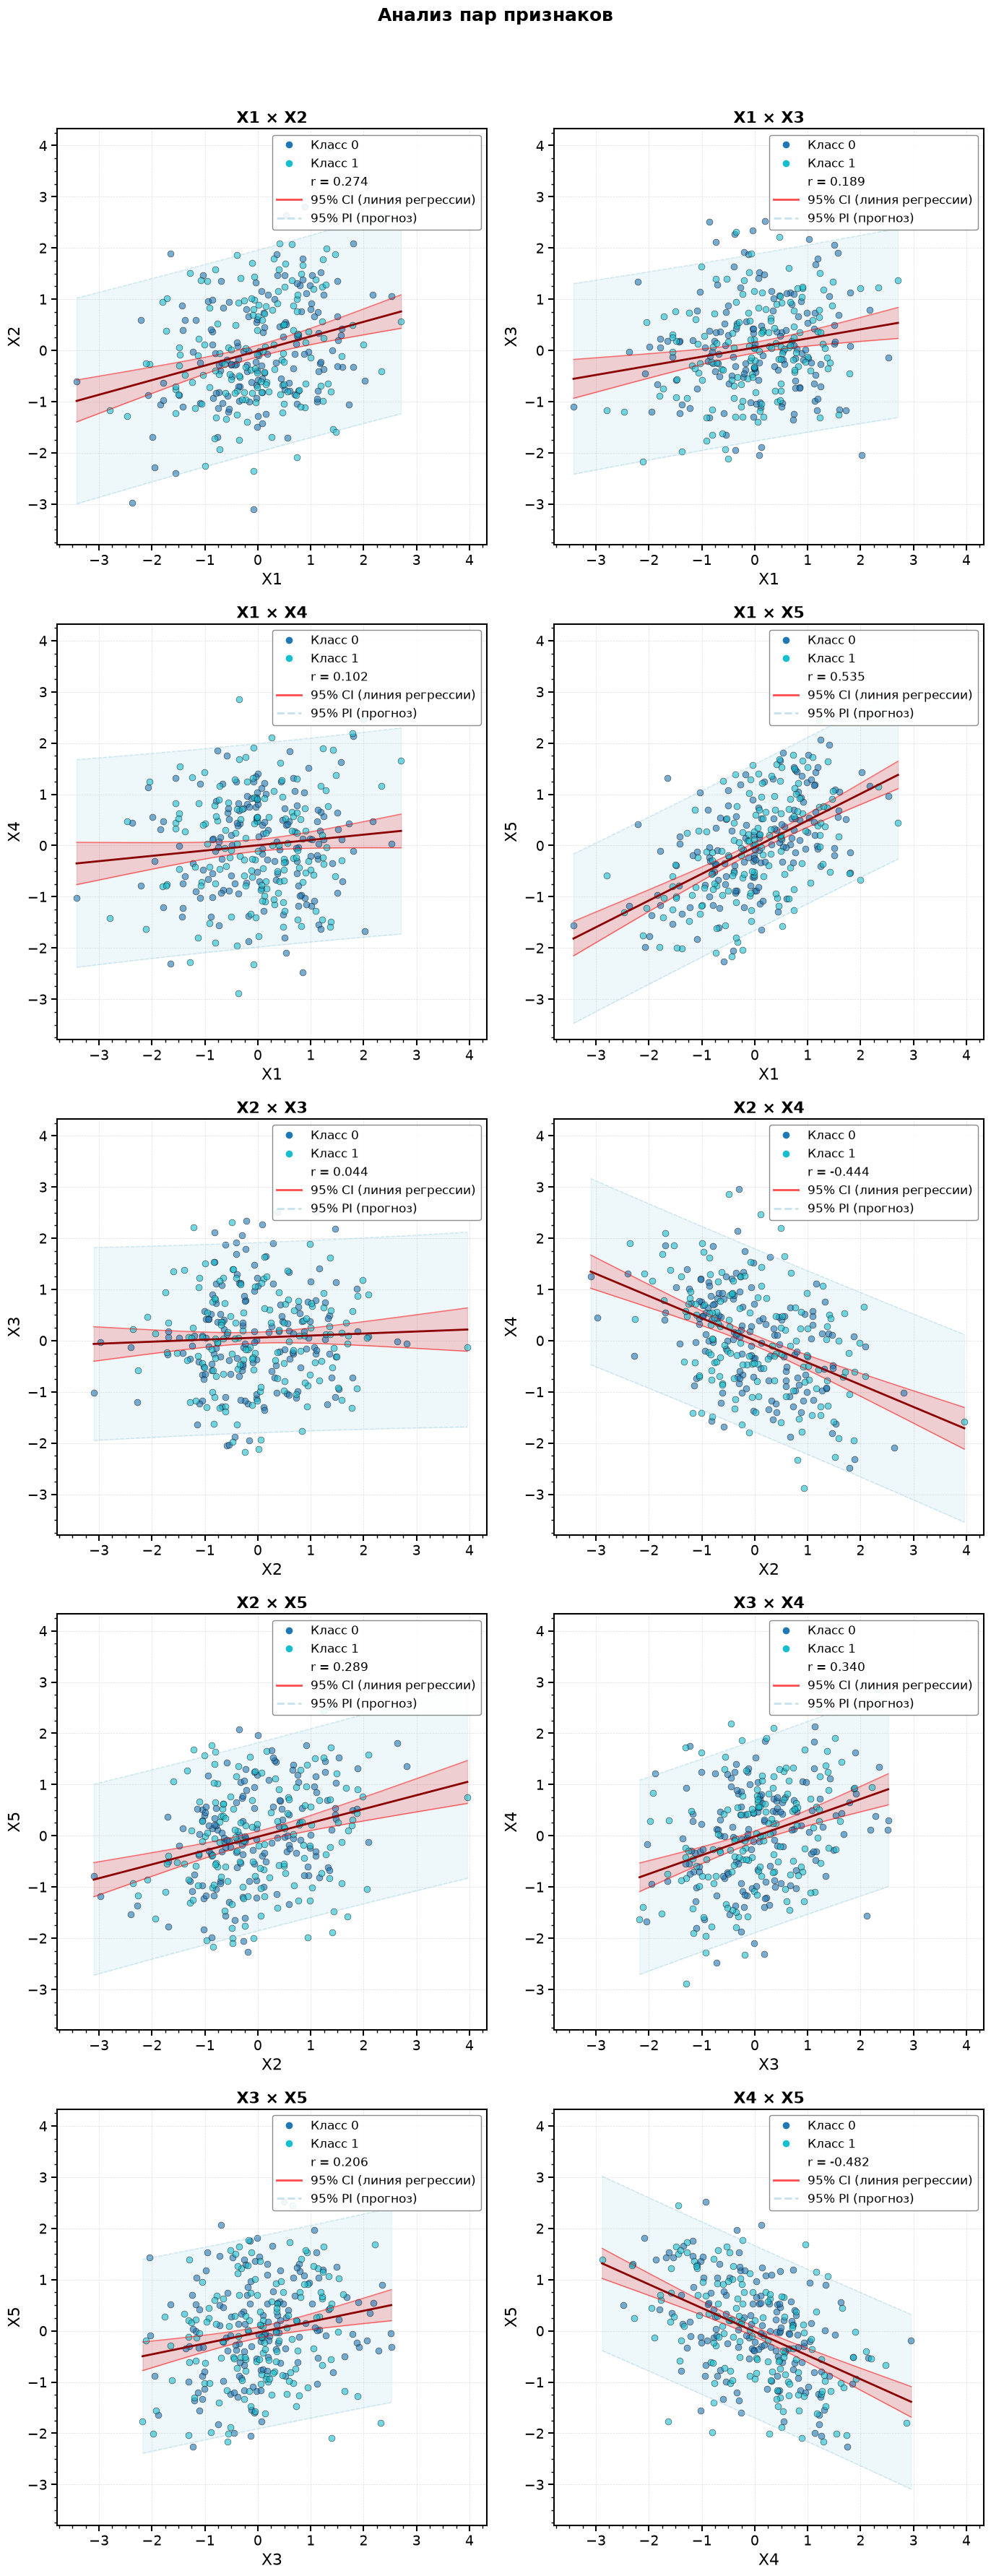

(<Figure size 1400x3500 with 10 Axes>,
 array([<Axes: title={'center': 'X1 × X2'}, xlabel='X1', ylabel='X2'>,
        <Axes: title={'center': 'X1 × X3'}, xlabel='X1', ylabel='X3'>,
        <Axes: title={'center': 'X1 × X4'}, xlabel='X1', ylabel='X4'>,
        <Axes: title={'center': 'X1 × X5'}, xlabel='X1', ylabel='X5'>,
        <Axes: title={'center': 'X2 × X3'}, xlabel='X2', ylabel='X3'>,
        <Axes: title={'center': 'X2 × X4'}, xlabel='X2', ylabel='X4'>,
        <Axes: title={'center': 'X2 × X5'}, xlabel='X2', ylabel='X5'>,
        <Axes: title={'center': 'X3 × X4'}, xlabel='X3', ylabel='X4'>,
        <Axes: title={'center': 'X3 × X5'}, xlabel='X3', ylabel='X5'>,
        <Axes: title={'center': 'X4 × X5'}, xlabel='X4', ylabel='X5'>],
       dtype=object))

In [55]:
plot_pairs(
    df,
    class_col="class",
    features=["X1", "X2", "X3", "X4", "X5"],
    
    # Размер панно
    subplot_size=7,
    max_cols=2,
    
    # Шрифт
    font_family="DejaVu Sans",
    font_size=16,
    
    # Точки
    point_size=40,
    point_color=None,  # автоматические цвета по классам
    point_alpha=0.6,
    point_edgecolor="black",
    point_linewidth=0.5,
    point_marker="o",  # "o" - круг, "s" - квадрат
    
    # Регрессия
    show_correlation=True,
    correlation_color="darkred",
    correlation_width=2,
    
    # Интервал предсказания
    show_prediction_interval=True,
    confidence_level=0.95,
    interval_color="lightblue",
    interval_alpha=0.2,
    interval_linestyle="--",
    interval_linewidth=1,
    
    # Интервалы значений
    show_intervals=True,
    
    # Легенда
    show_legend=True,
    
    # Сетка
    show_grid=True,
    
    # Масштаб
    equal_scale=False,
    scale_mode="global",
    
    suptitle="Анализ пар признаков",
    suptitle_size=18,
    
    # Доверительный интервал линии регрессии
    show_confidence_band=True,
    confidence_band_color="red",
    confidence_band_alpha=0.2,
    confidence_band_level=0.95,
)